In [8]:
! pip install "unstructured[all-docs]" pillow pydantic lxml matplotlib

In [7]:
!sudo apt-get update
!sudo apt-get install poppler-utils


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: dpkg was interrupted, you must manually run 'sudo dpkg --configure 

In [9]:
!sudo apt-get install libleptonica-dev tesseract-ocr libtesseract-dev python3-pil tesseract-ocr-eng tesseract-ocr-script-latn


E: dpkg was interrupted, you must manually run 'sudo dpkg --configure -a' to correct the problem. 


In [10]:
!pip install unstructured-pytesseract
!pip install tesseract-ocr

In [11]:
from unstructured.partition.pdf import partition_pdf

In [13]:
raw_pdf_elements=partition_pdf(
    filename="/content/pdf1.pdf",
    strategy="hi_res",
    extract_images_in_pdf=True,
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=False,
    extract_image_block_output_dir="extracted_data"
  )

In [14]:
raw_pdf_elements

In [15]:
Header=[]
Footer=[]
Title=[]
NarrativeText=[]
Text=[]
ListItem=[]


for element in raw_pdf_elements:
  if "unstructured.documents.elements.Header" in str(type(element)):
            Header.append(str(element))
  elif "unstructured.documents.elements.Footer" in str(type(element)):
            Footer.append(str(element))
  elif "unstructured.documents.elements.Title" in str(type(element)):
            Title.append(str(element))
  elif "unstructured.documents.elements.NarrativeText" in str(type(element)):
            NarrativeText.append(str(element))
  elif "unstructured.documents.elements.Text" in str(type(element)):
            Text.append(str(element))
  elif "unstructured.documents.elements.ListItem" in str(type(element)):
            ListItem.append(str(element))

In [16]:
NarrativeText # content

['Yunfan Gaoa, Yun Xiongb, Xinyu Gaob, Kangxiang Jiab, Jinliu Panb, Yuxi Bic, Yi Daia, Jiawei Suna, Meng Wangc, and Haofen Wang a,c',
 'aShanghai Research Institute for Intelligent Autonomous Systems, Tongji University bShanghai Key Laboratory of Data Science, School of Computer Science, Fudan University cCollege of Design and Innovation, Tongji University',
 'Abstract—Large Language Models (LLMs) showcase impres- sive capabilities but encounter challenges like hallucination, outdated knowledge, and non-transparent, untraceable reasoning processes. Retrieval-Augmented Generation (RAG) has emerged as a promising solution by incorporating knowledge from external databases. This enhances the accuracy and credibility of the generation, particularly for knowledge-intensive tasks, and allows for continuous knowledge updates and integration of domain- specific information. RAG synergistically merges LLMs’ intrin- sic knowledge with the vast, dynamic repositories of external databases. This co

In [17]:
ListItem # points, bullet

['• In this survey, we present a thorough and systematic review of the state-of-the-art RAG methods, delineating its evolution through paradigms including naive RAG,',
 '• We identify and discuss the central technologies integral to the RAG process, specifically focusing on the aspects of “Retrieval”, “Generation” and “Augmentation”, and delve into their synergies, elucidating how these com- ponents intricately collaborate to form a cohesive and effective RAG framework.',
 '• We have summarized the current assessment methods of RAG, covering 26 tasks, nearly 50 datasets, outlining the evaluation objectives and metrics, as well as the current evaluation benchmarks and tools. Additionally, we anticipate future directions for RAG, emphasizing potential enhancements to tackle current challenges.',
 '[1] N. Kandpal, H. Deng, A. Roberts, E. Wallace, and C. Raffel, “Large language models struggle to learn long-tail knowledge,” in Interna- tional Conference on Machine Learning. PMLR, 2023, pp.

In [18]:
img=[]
for element in raw_pdf_elements:
  if "unstructured.documents.elements.Image" in str(type(element)):
            img.append(str(element))

In [19]:
img[0]

'Fine-tuning 2023 Retrieval—Augmented Generation Pre-training Inference RADA, Eicee'

In [20]:
tab=[]
for element in raw_pdf_elements:
  if "unstructured.documents.elements.Table" in str(type(element)):
            tab.append(str(element))

In [21]:
tab

['Retrieval Source Retrieval Data Type Wikipedia Text FactoidWiki Text Dataset-base Text Dataset-base Text Dataset-base Text Dataset-base Text Search Engine,Wikipedia Text Wikipedia Text Wikipedia Text Dataset-base Text Synthesized dataset Text Dataset-base Text Dataset-base Text Dataset-base Text Dataset-base Text Dataset-base Text Synthesized dataset Text Wikipedia, Common Crawl Text Wikipedia Text Pre-training Corpus Text Pre-training corpus Text Search Engine Text Dataset-base Text BEIR Text MSMARCO,Wikipedia Text Common Crawl,Wikipedia Text Wikipedia Text Dataset-base Text Wikipedia Text Wikipedia Text Wikipedia Text Wikipedia Text Wikipedia Text Arxiv,Online Database,PubMed Text FactoidWiki Text Search Engine,Wikipedia Text Wikipedia Text Search Engine,Wikipedia Text Dataset-base,Wikipedia Text Wikipedia Text Dataset-base Text Wikipedia Text Wikipedia Text Wikipedia Text Dataset-base Text LLMs Text Pile,Wikipedia Text Dataset-base Text C4 Text Arxiv Text Wikipedia Text Dataset-ba

In [22]:
!pip install langchain_community openai tiktoken rapidocr-onnxruntime
!pip install langchain_openai
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain.prompts import ChatPromptTemplate

In [23]:
len(img)

6

In [24]:
len(tab)

4

In [25]:
# Prompt
prompt_text = """You are an assistant tasked with summarizing tables for retrieval. \
    These summaries will be embedded and used to retrieve the raw table elements. \
    Give a concise summary of the table that is well optimized for retrieval. Table {element} """

In [26]:
prompt = ChatPromptTemplate.from_template(prompt_text)

In [27]:

import os
from google.colab import userdata
OPENAI_API_TOKEN=userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = OPENAI_API_TOKEN

In [28]:
model = ChatOpenAI(temperature=0, model="gpt-4")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [29]:
table_summaries = []
table_summaries = summarize_chain.batch(tab,{"max_concurrency": len(tab)})
table_summaries

['The table provides a comprehensive list of various sources used for data retrieval, including Wikipedia, Dataset-base, Search Engine, Synthesized dataset, Common Crawl, Pre-training Corpus, BEIR, MSMARCO, Arxiv, Online Database, PubMed, FactoidWiki, LLMs, Pile, and C4. The data types are predominantly text, with retrieval granularity ranging from phrases and propositions to sentences, item-base, chunks, and documents. The table also outlines the augmentation stage for each source, including pre-training, inference, and tuning stages.',
 'The table categorizes various datasets and tasks in the field of natural language processing and machine learning. It includes single-hop and multi-hop question answering tasks with datasets like Natural Question, TriviaQA, SQuAD, and HotpotQA. It also mentions long-form QA tasks like ELI5 and NarrativeQA. The table includes domain-specific QA tasks like Qasper and COVID-QA, and multi-choice QA tasks like QuALITY and ARC. It also lists tasks related 

In [30]:
table_summaries[0]

'The table provides a comprehensive list of various sources used for data retrieval, including Wikipedia, Dataset-base, Search Engine, Synthesized dataset, Common Crawl, Pre-training Corpus, BEIR, MSMARCO, Arxiv, Online Database, PubMed, FactoidWiki, LLMs, Pile, and C4. The data types are predominantly text, with retrieval granularity ranging from phrases and propositions to sentences, item-base, chunks, and documents. The table also outlines the augmentation stage for each source, including pre-training, inference, and tuning stages.'

In [31]:

import base64
import os
from langchain_core.messages import HumanMessage

In [32]:

def encode_image(image_path):
    """Getting the base64 string"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

def image_summarize(img_base64, prompt):
    """Make image summary"""


    chat = ChatOpenAI(model="gpt-4o-mini", max_tokens=1024)

    msg = chat.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},

                     {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content

In [33]:
def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """

    # Store base64 encoded images
    img_base64_list = []

    # Store image summaries
    image_summaries = []

    # Prompt
    prompt = """You are an assistant tasked with summarizing images for retrieval. \
    These summaries will be embedded and used to retrieve the raw image. \
    Give a concise summary of the image that is well optimized for retrieval."""

    # Apply to images
    for img_file in sorted(os.listdir(path)):
        if img_file.endswith(".jpg"):
            img_path = os.path.join(path, img_file)
            base64_image = encode_image(img_path)
            img_base64_list.append(base64_image)
            image_summaries.append(image_summarize(base64_image, prompt))


    return img_base64_list, image_summaries

In [34]:
fpath="/content/extracted_data/"
img_base64_list,image_summaries=generate_img_summaries(fpath)

In [35]:
image_summaries

['Flowchart illustrating three strategies for information processing: **Iterative**, **Recursive**, and **Adaptive**. Each section shows a structured approach involving querying, retrieving data, generating responses, and judging the output based on specific criteria. The **Iterative** method emphasizes repeated retrieval and generation, while the **Recursive** method focuses on breaking down complex queries step by step. The **Adaptive** method incorporates flexible retrieval and generation with on-demand capabilities.',
 'The image illustrates the RAG (Retrieval-Augmented Generation) ecosystem, detailing downstream tasks (like dialogue and summarization) and technology stacks (including Langchain and FlowiseAI). It discusses the RAG paradigm, contrasting Naive RAG with Advanced and Modular RAG. Techniques for optimizing RAG are highlighted, including chunk optimization and query transformation. Challenges in RAG implementation are noted, along with modality extensions for various med

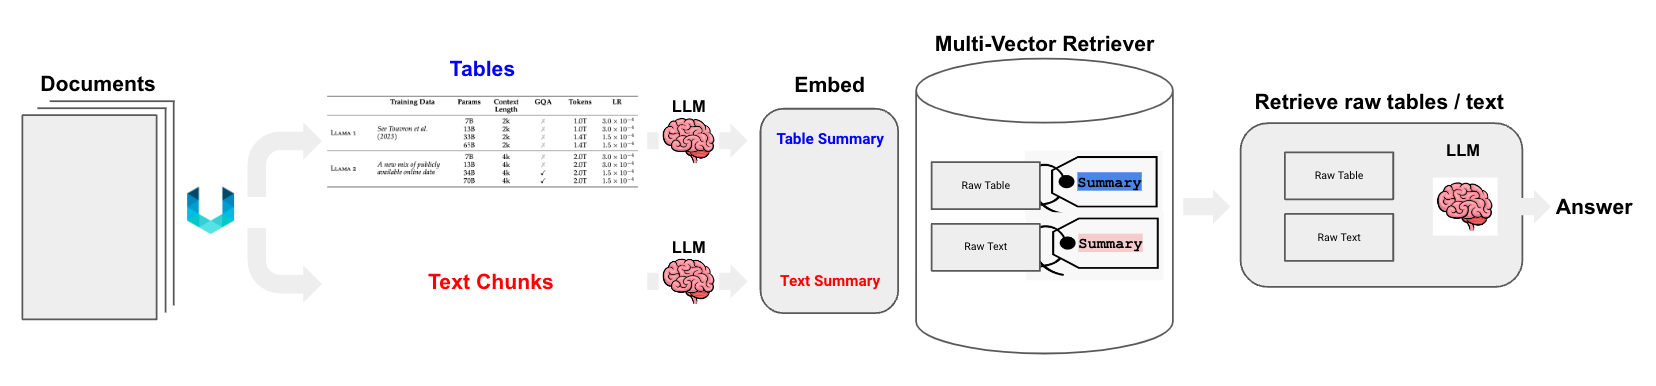

In [5]:

import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_community.embeddings import OpenAIEmbeddings


In [34]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.4/177.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 7.9 MB/s eta 0:

In [2]:
from chromadb import Chroma

ImportError: cannot import name 'Chroma' from 'chromadb' (/usr/local/lib/python3.11/dist-packages/chromadb/__init__.py)

In [36]:
def create_multi_vector_retriever(vectorstore, text_summaries, texts, table_summaries, tables, image_summaries, images):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """

    # Initialize the storage layer
    store = InMemoryStore()
    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=store,
        id_key=id_key,
    )


    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):

      doc_ids = [str(uuid.uuid4()) for _ in doc_contents]

      summary_docs = [
              Document(page_content=s, metadata={id_key: doc_ids[i]})
              for i, s in enumerate(doc_summaries)
          ]

      retriever.vectorstore.add_documents(summary_docs)
      retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

      # Add texts, tables, and images
      # Check that text_summaries is not empty before adding
      if text_summaries:
          add_documents(retriever, text_summaries, texts)
      # Check that table_summaries is not empty before adding
      if table_summaries:
          add_documents(retriever, table_summaries, tab)
      # Check that image_summaries is not empty before adding
      if image_summaries:
          add_documents(retriever, image_summaries, img)

    return retriever

vectorstore = Chroma(
    collection_name="mm_rag", embedding_function=OpenAIEmbeddings()
)

# Create retriever
retriever_multi_vector_img = create_multi_vector_retriever(
    vectorstore,
    text_summaries,
    Text,
    table_summaries,
    Table,
    image_summaries,
    img_base64_list,
)

<ipython-input-36-a718a30699c4>:44: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(


NameError: name 'text_summaries' is not defined

In [ ]:
retriever_multi_vector_img

In [ ]:
import io
import re

from IPython.display import HTML, display
from PIL import Image

In [ ]:
def plt_img_base64(img_base64):
    """Disply base64 encoded string as image"""
    # Create an HTML img tag with the base64 string as the source
    image_html = f''
    # Display the image by rendering the HTML
    display(HTML(image_html))

In [ ]:
plt_img_base64(img_base64_list[1])

In [ ]:
image_summaries[1]